In [4]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_diamonds = sns.load_dataset("diamonds")
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df_diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [5]:
x = df_diamonds["carat"].values.reshape(-1,1)
y = df_diamonds["price"].values.reshape(-1,1)

In [6]:
X_train, Y_test, Y_train, X_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [7]:
regressor = LinearRegression()
regressor.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = regressor.predict(X_train)

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

print("Coeficiente: \n" , regressor.coef_)
print("Independiente termino: \n " , regressor.intercept_)
print("Mean squared error: %.2f" % mean_squared_error(Y_train, y_pred))

Coeficiente: 
 [[7741.37904828]]
Independiente termino: 
  [-2247.70447085]
Mean squared error: 2408781.08


In [10]:
print(regressor.score(X_test,Y_test))
print("Varianza: %.2f" % r2_score(Y_train, y_pred))

-8427534821816906.0
Varianza: 0.85


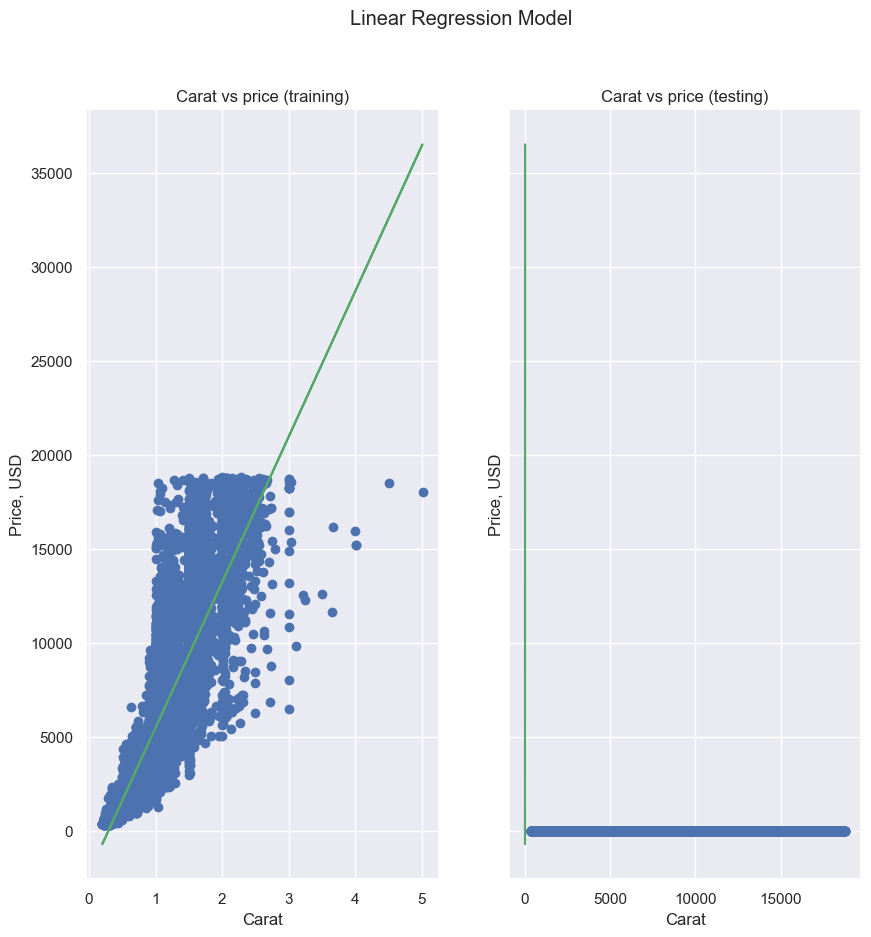

In [11]:
sns.set_theme()

fig, ax = plt.subplots(1, 2, figsize=(10, 10), sharey=True)

ax[0].scatter(X_train, Y_train)
ax[0].plot(X_train, regressor.predict(X_train), c='g')
ax[0].set_title('Carat vs price (training)')
ax[0].set_xlabel('Carat')
ax[0].set_ylabel('Price, USD')

ax[1].scatter(X_test, Y_test)
ax[1].plot(X_train, regressor.predict(X_train), c='g')
ax[1].set_title('Carat vs price (testing)')
ax[1].set_xlabel('Carat')
ax[1].set_ylabel('Price, USD')

plt.suptitle('Linear Regression Model')
plt.show()


In [12]:
xx = df_diamonds[['carat', 'z']].values
yy = df_diamonds['price'].values.reshape(-1, 1)

XX_train, XX_test, YY_train, YY_test = train_test_split(
    xx, yy, test_size=0.3, random_state=0
)

regressor.fit(XX_train, YY_train)
regressor.score(XX_test, YY_test)

0.8552958757573261

Conclusion. 

- Pudimos predecir el precio de un diamante a partir del peso en quilates, pude ver que tiene buena relacion entre peso y precio , pero no pudo ser muy preciso por los datos , si se incluye otra variable independiente , el modelo mejora.